In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score 
#import ipywidgets as widgets
import ipywidgets as widgets


In [2]:
def load(path):
    # Load
    df = pd.read_excel(path)
    col_checker = ['DATEPRD', 'BORE_OIL_VOL', 'WELL_BORE_CODE']
    #if any col_checkers in df.columns:
    for col in col_checker:
        if col in df.columns:
         #replace DATEPRD with TEST_DATE and BORE_OIL_VOL with OIL
            if col == 'DATEPRD':
                df.rename(columns={col: 'TEST_DATE'}, inplace=True)
                df['TEST_DATE'] = pd.to_datetime(df['TEST_DATE'])
            elif col == 'BORE_OIL_VOL':
                df.rename(columns={col: 'OIL'}, inplace=True)
            elif col=='WELL_BORE_CODE':
                df.rename(columns={col:'WELL_NAME'},inplace=True)
    if 'TEST_DATE' in df.columns:
        df['TEST_DATE'] = pd.to_datetime(df['TEST_DATE'], errors='coerce')
    return df




In [3]:

# Make features functions
def make_features_01(df):
    #only use TEST_DATE as time index and OIL as target variable
    df['t'] = (df['TEST_DATE'] - df['TEST_DATE'].min()).dt.days
    return df

def make_features_02(df):
    # use TEST_DATE as time index
    df['t'] = (df['TEST_DATE'] - df['TEST_DATE'].min()).dt.days
    # Create lag features for the target variable
    df['rate_1']=df['OIL'].shift(1)
    df['rate_2']=df['OIL'].shift(2)
    df['rate_3']=df['OIL'].shift(3)
    #replace 0 with NaN and Dropna for all new features
    df[['OIL','rate_1','rate_2','rate_3']] = df[['OIL','rate_1','rate_2','rate_3']].replace(0, np.nan)
    df = df.dropna(subset=['OIL', 'rate_1', 'rate_2', 'rate_3'])
    return df

def make_features_03(df):
     # use TEST_DATE as time index
    df['t'] = (df['TEST_DATE'] - df['TEST_DATE'].min()).dt.days
    df['1/logq']=1/np.log(df['OIL'].replace(0, np.nan))
    #rolling mean
    df['q_rolling_mean'] = df['OIL'].rolling(window=3, min_periods=1).mean()
    #dq/dt
    df['dq_dt'] = df['OIL'].diff() / df['t'].diff()
    #logq
    df['logq'] = np.log(df['OIL'].replace(0, np.nan))
    # Replace zeros to avoid log/ratio issues
    df['q'] = df['OIL'].replace(0, np.nan)
    return df



In [4]:
def plot_data(data):
    plt.figure(figsize=(10, 6))
    plt.scatter(data['TEST_DATE'], data['OIL'], label='Oil', color='blue')
    plt.xlabel('Time (days)')
    plt.ylabel('Production (bbl/day)')
    plt.title(data['WELL_NAME'].iloc[0])
    plt.legend()
    plt.grid()
    plt.show()



In [ ]:
path='/home/rian/python_project/myvenv/dca_ml/data/Volve production data.xlsx'
data=load(path)
df=data[['TEST_DATE','OIL','WELL_NAME']]
well_name = "NO 15/9-F-12 H"
df = df[df['WELL_NAME'] == well_name]
#grab max min date value
min_date = df['TEST_DATE'].min()
max_date = df['TEST_DATE'].max()
#make a slider to select date range for OIL production data
date_range_slider = widgets.SelectionRangeSlider(
    options=[(date.strftime('%Y-%m-%d'), date) for date in pd.date_range(min_date, max_date)],
    index=(0, len(pd.date_range(min_date, max_date)) - 1),
    description='Date Range',
    orientation='horizontal',
    layout={'width': '500px'}
)

plot_output = widgets.Output()
table_output = widgets.Output()
slided_df = pd.DataFrame(columns=df.columns)

def get_slided_df():
    # Use this in other cells to work on a regular dataframe copy
    return slided_df.copy()

def update_plot(change):
    global slided_df
    start_date, end_date = change['new']
    slided_df = df[(df['TEST_DATE'] >= start_date) & (df['TEST_DATE'] <= end_date)].copy().reset_index(drop=True)

    with plot_output:
        plot_output.clear_output(wait=True)
        plot_data(slided_df)

    with table_output:
        table_output.clear_output(wait=True)
        display(slided_df)

date_range_slider.observe(update_plot, names='value')

# Render slider + reusable output areas
update_plot({'new': date_range_slider.value})
display(widgets.VBox([date_range_slider, plot_output, table_output]))

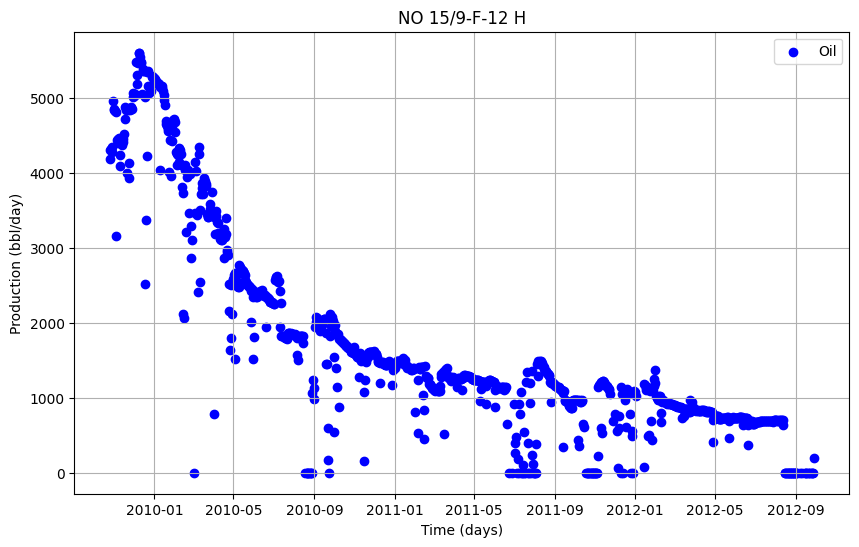

In [11]:
work_df = get_slided_df()
plot_data(work_df)

In [12]:
work_df.to_csv('/home/rian/python_project/myvenv/dca_ml/data/selected_data_02.csv', index=False)

In [13]:
#dca_df = make_features_01(work_df)
#dca_df = make_features_02(work_df)
dca_df = make_features_03(work_df)
split = int(len(dca_df) * 0.8)
train_dates = dca_df['TEST_DATE'].iloc[:split]
test_dates = dca_df['TEST_DATE'].iloc[split:]
X_train, X_test = dca_df.iloc[:split], dca_df.iloc[split:]
y_train, y_test = dca_df['OIL'].iloc[:split], dca_df['OIL'].iloc[split:]
#feature_cols = ['t']
#feature_cols = ["OIL","rate_1","rate_2","rate_3"]
feature_cols = ['t','1/logq','q_rolling_mean','dq_dt','logq','q']

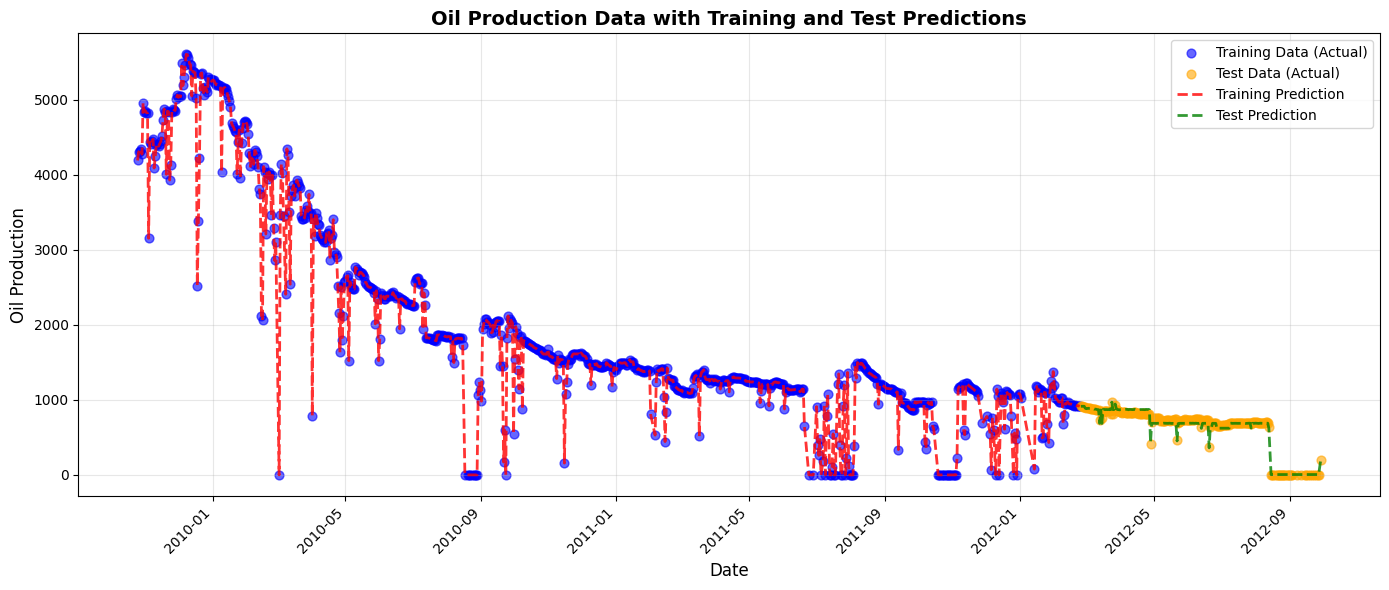

In [14]:
# Train a model and get predictions for the current train/test split
# model = RandomForestRegressor(n_estimators=100, random_state=42)
model = XGBRegressor(n_estimators=100, random_state=42)
model.fit(X_train[feature_cols], y_train)

# Make predictions
y_train_pred_current = model.predict(X_train[feature_cols])
y_test_pred_current = model.predict(X_test[feature_cols])

# Create figure and axis
fig, ax = plt.subplots(figsize=(14, 6))

# Scatter plot for actual oil data
ax.scatter(train_dates, y_train, alpha=0.6, s=40, label='Training Data (Actual)', color='blue')
ax.scatter(test_dates, y_test, alpha=0.6, s=40, label='Test Data (Actual)', color='orange')

# Line plots for predictions
ax.plot(train_dates, y_train_pred_current, color='red', linewidth=2, linestyle='--', alpha=0.8, label='Training Prediction')
ax.plot(test_dates, y_test_pred_current, color='green', linewidth=2, linestyle='--', alpha=0.8, label='Test Prediction')

# Labels and formatting
ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('Oil Production', fontsize=12)
ax.set_title('Oil Production Data with Training and Test Predictions', fontsize=14, fontweight='bold')
ax.legend(loc='best', fontsize=10)
ax.grid(True, alpha=0.3)

# Rotate x-axis labels for better readability
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

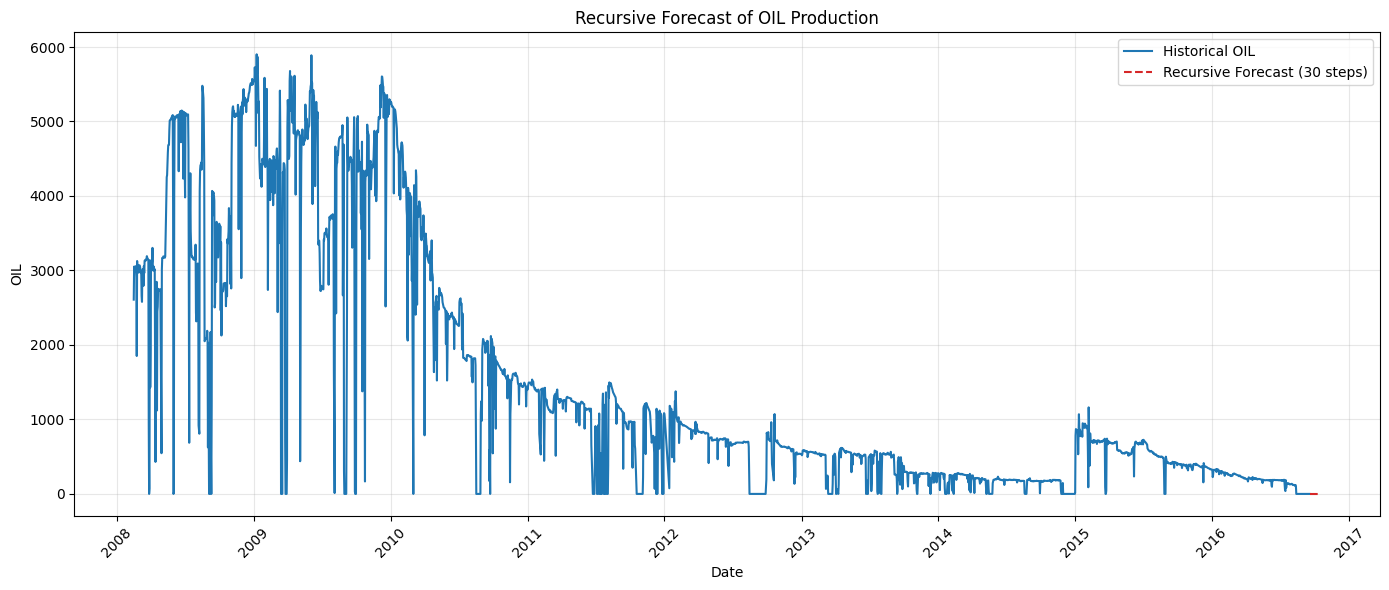

,TEST_DATE,FORECAST_OIL
0,2016-09-18,0.0
1,2016-09-19,0.0
2,2016-09-20,0.0
3,2016-09-21,0.0
4,2016-09-22,0.0
5,2016-09-23,0.0
6,2016-09-24,0.0
7,2016-09-25,0.0
8,2016-09-26,0.0
9,2016-09-27,0.0


In [10]:
# Recursive multi-step forecast (uses previous predictions as next lags)
rec_df = work_df[['TEST_DATE', 'OIL']].copy().sort_values('TEST_DATE').reset_index(drop=True)
rec_df['TEST_DATE'] = pd.to_datetime(rec_df['TEST_DATE'])

# Build time index in days from first date
rec_df['t'] = (rec_df['TEST_DATE'] - rec_df['TEST_DATE'].min()).dt.days

# Create lag features
rec_df['rate_1'] = rec_df['OIL'].shift(1)
rec_df['rate_2'] = rec_df['OIL'].shift(2)
rec_df['rate_3'] = rec_df['OIL'].shift(3)
rec_df = rec_df.dropna(subset=['OIL', 'rate_1', 'rate_2', 'rate_3']).reset_index(drop=True)

# Train recursive model
X_rec = rec_df[['t', 'rate_1', 'rate_2', 'rate_3']]
y_rec = rec_df['OIL']
forecast_model = RandomForestRegressor(n_estimators=300, random_state=42)
forecast_model.fit(X_rec, y_rec)

# Forecast horizon (uses existing horizon if defined)
horizon = int(globals().get('horizon', 30))

# Estimate future spacing from historical cadence
step_days = int(rec_df['TEST_DATE'].diff().dt.days.dropna().median())
if step_days <= 0:
    step_days = 1

last_date = rec_df['TEST_DATE'].iloc[-1]
last_t = int(rec_df['t'].iloc[-1])
lag1 = float(rec_df['OIL'].iloc[-1])
lag2 = float(rec_df['OIL'].iloc[-2])
lag3 = float(rec_df['OIL'].iloc[-3])

future_dates = []
future_pred = []

for step in range(1, horizon + 1):
    t_next = last_t + step * step_days
    x_future = pd.DataFrame([{
        't': t_next,
        'rate_1': lag1,
        'rate_2': lag2,
        'rate_3': lag3
    }])

    y_hat = float(forecast_model.predict(x_future)[0])
    y_hat = max(0.0, y_hat)

    next_date = last_date + pd.Timedelta(days=step * step_days)
    future_dates.append(next_date)
    future_pred.append(y_hat)

    lag3, lag2, lag1 = lag2, lag1, y_hat

forecast_df = pd.DataFrame({'TEST_DATE': future_dates, 'FORECAST_OIL': future_pred})

# Plot history + recursive forecast
plt.figure(figsize=(14, 6))
plt.plot(rec_df['TEST_DATE'], rec_df['OIL'], label='Historical OIL', color='tab:blue')
plt.plot(forecast_df['TEST_DATE'], forecast_df['FORECAST_OIL'], label=f'Recursive Forecast ({horizon} steps)', color='tab:red', linestyle='--')
plt.title('Recursive Forecast of OIL Production')
plt.xlabel('Date')
plt.ylabel('OIL')
plt.grid(alpha=0.3)
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

forecast_df.head(10)